In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# loading dataset
data = load_breast_cancer()
X, y = data.data, data.target
X.shape, y.shape

((569, 30), (569,))

In [3]:
X[0]

array([1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
       3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
       8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
       3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
       1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01])

In [4]:
y[0]

np.int64(0)

In [5]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [6]:
# splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
# data standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# defining model
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)), # Input
    layers.Dense(32, activation="relu"), # layer 1 with 32 neurons
    layers.Dropout(0.3), # 30% of neurons in the previous layer are randomly turned off during each training step
    layers.Dense(16, activation="relu"), # layer 2 with 16 neurons
    layers.Dense(1, activation="sigmoid")  # layer 3 with 1 neuron
])

In [9]:
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [10]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.6786 - loss: 0.7185 - val_accuracy: 0.7033 - val_loss: 0.5728
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8049 - loss: 0.4448 - val_accuracy: 0.8901 - val_loss: 0.4025
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8956 - loss: 0.3476 - val_accuracy: 0.9231 - val_loss: 0.2810
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9231 - loss: 0.2546 - val_accuracy: 0.9231 - val_loss: 0.2076
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9368 - loss: 0.1977 - val_accuracy: 0.9341 - val_loss: 0.1654
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9533 - loss: 0.1561 - val_accuracy: 0.9341 - val_loss: 0.1373
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9478 - loss: 0.1340 - val_accuracy: 0.9560 - val_loss: 0.1159
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9615 - loss: 0.1305 - val_accuracy: 0.9560 - v

In [11]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")


Test Accuracy: 0.9649


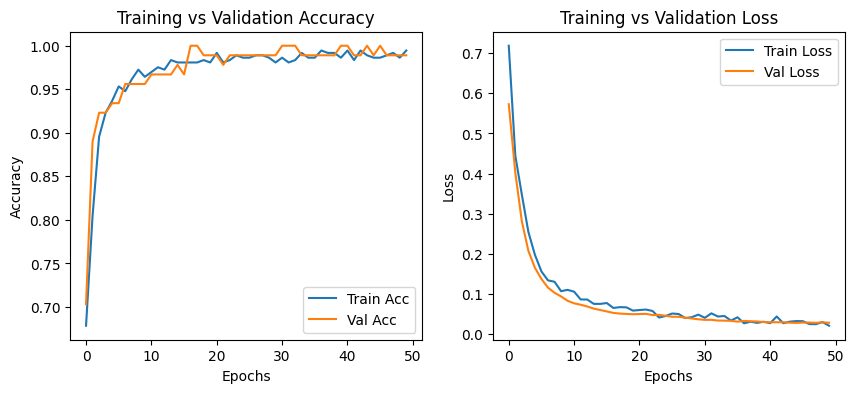

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# plotting accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# plotting loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

#### Assignment
- Train a feed-forward neural network to solve a multi-class classification task. You can use a dataset of your choice from scikit-learn or kaggle. Use the ``Weights and Biases`` Python library for visualization during model training, and take screenshots of your dashboard. Compute relevant performance metrics and save your model.
- Use the PyTorch Python library to train a feedforward neural network to solve a regression task. You can use a dataset of your choice. Implement checkpointing and earlystopping. Compute relevant performance metrics and save your best model

Qn. 1

Train a feed-forward neural network to solve a multi-class classification task. You can use a dataset of your choice from scikit-learn or kaggle. Use the ``Weights and Biases`` Python library for visualization during model training, and take screenshots of your dashboard. Compute relevant performance metrics and save your model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import wandb
wandb.login(key="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")
from wandb.integration.keras import WandbCallback

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\byamu\_netrc
wandb: Currently logged in as: byamugishanthony (models-makerere-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [2]:
# Initialize Weights & Biases
wandb.init(project="wine-classification-ffnn")

In [3]:
# loading dataset
data = load_wine()
X = data.data
y = data.target
class_names = data.target_names

## Creating a DataFrame using feature names for columns
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
# splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# data standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
# defining the model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

In [8]:
# compiling the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
# training the model with Weights & Biases callback
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    callbacks=[WandbCallback(save_model=False, save_graph=False)] 
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0242
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0241
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0241
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0241
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0241
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.0241
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.0241
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.0242


In [16]:
# evaluating the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 0.0016
Test Accuracy: 1.0


In [17]:
# making predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


In [18]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



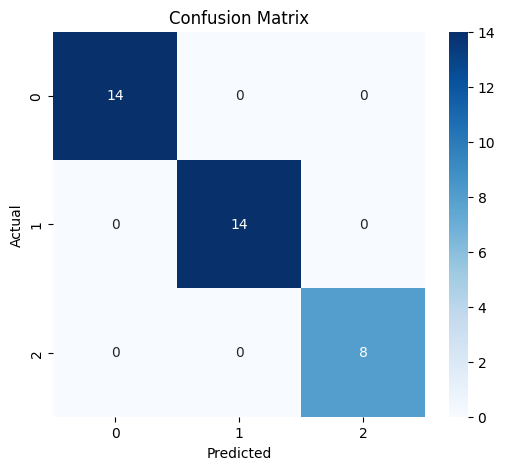

In [24]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
# saving the model
model.save("wine_ffnn_model.h5")

Qn 2

Use the PyTorch Python library to train a feedforward neural network to solve a regression task. You can use a dataset of your choice. Implement checkpointing and earlystopping. Compute relevant performance metrics and save your best model

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [27]:
# loading dataset
data = fetch_california_housing()
X = data.data
y = data.target

In [28]:
# splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
# data standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
# converting to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [ ]:
# defining the model
class FFNN(nn.Module):
    def __init__(self):
        super(FFNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(X_train.shape[1], 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = FFNN()


In [32]:
# defining loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [33]:
best_loss = float('inf')
patience = 10
counter = 0

train_losses = []
val_losses = []

for epoch in range(100):
    #training
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    # validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test)
        val_loss = criterion(val_outputs, y_test)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    print(f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

    # Checkpointing
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1

    #early stopping
    if counter >= patience:
        print("Early stopping triggered")
        break

Epoch 1, Train Loss: 5.7453, Val Loss: 5.5233
Epoch 2, Train Loss: 5.6275, Val Loss: 5.4105
Epoch 3, Train Loss: 5.5110, Val Loss: 5.2989
Epoch 4, Train Loss: 5.3957, Val Loss: 5.1883
Epoch 5, Train Loss: 5.2814, Val Loss: 5.0786
Epoch 6, Train Loss: 5.1678, Val Loss: 4.9692
Epoch 7, Train Loss: 5.0547, Val Loss: 4.8604
Epoch 8, Train Loss: 4.9418, Val Loss: 4.7518
Epoch 9, Train Loss: 4.8288, Val Loss: 4.6435
Epoch 10, Train Loss: 4.7156, Val Loss: 4.5353
Epoch 11, Train Loss: 4.6021, Val Loss: 4.4273
Epoch 12, Train Loss: 4.4883, Val Loss: 4.3189
Epoch 13, Train Loss: 4.3742, Val Loss: 4.2106
Epoch 14, Train Loss: 4.2599, Val Loss: 4.1022
Epoch 15, Train Loss: 4.1454, Val Loss: 3.9942
Epoch 16, Train Loss: 4.0307, Val Loss: 3.8862
Epoch 17, Train Loss: 3.9162, Val Loss: 3.7787
Epoch 18, Train Loss: 3.8020, Val Loss: 3.6717
Epoch 19, Train Loss: 3.6885, Val Loss: 3.5653
Epoch 20, Train Loss: 3.5754, Val Loss: 3.4599
Epoch 21, Train Loss: 3.4633, Val Loss: 3.3556
Epoch 22, Train Loss: 

In [34]:
# loading the best model
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [35]:
# making predictions
model.eval()
with torch.no_grad():
    y_pred = model(X_test).numpy()

In [36]:
# evaluating the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.599483847618103
MSE: 0.6860131621360779
RMSE: 0.8282591153353387
R2 Score: 0.47648924589157104


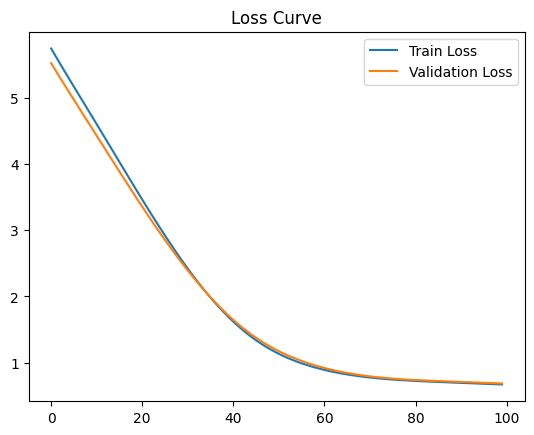

In [37]:
# plotting loss curves
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()